# AI for Cognitive Ultrasound Imaging
**IEEE IUS 2026 Short Course**

In this tutorial, we reconstruct a cardiac ultrasound sequence using a subset of the recording's
56 focused scan lines per frame. We start from raw channel data and beamform all lines, then
only a few of them: this saves acquisition time, but leaves most of the image unobserved.
Filling in the missing lines is an inverse problem, which we solve with a pretrained
flow-matching model that acts as a prior. The model generates possible reconstructions
from the available measurements, and we use the variance in those reconstructions to
choose which lines to acquire next.

We'll first reconstruct one frame, then repeat the process over a sequence and compare it
with random and evenly spaced line selection. This is a **perception-action loop**:
acquire lines → reconstruct the current frame → choose lines for the next frame.

We replay raw channel data from a parasternal long-axis (PLAX) recording acquired with a
Verasonics Vantage 256 research ultrasound system and Philips S5-1 phased array, beamforming the scan lines using `zea`.

This notebook accompanies the IEEE IUS 2026 short course
[AI for Cognitive Ultrasound Imaging](https://ieee-ius.org/2026/short-course/ai-for-cognitive-ultrasound-imaging),
organized by Yonina Eldar, Marcin Lewandowski and Ruud van Sloun. The tutorial is brought to you
by [Tristan Stevens](https://github.com/tristan-deep), [Oisín Nolan](https://github.com/OisinNolan), [Wessel van Nierop](https://github.com/wesselvannierop) and [Simon Penninga](https://github.com/swpenninga), maintainers of [`zea`](https://github.com/tue-bmd/zea).


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/ius-2026-cogus-workshop/blob/main/ius_2026_cogus_workshop.ipynb)
&nbsp;
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/ius-2026-cogus-workshop/blob/main/ius_2026_cogus_workshop.ipynb)
&nbsp;
[![Hugging Face model](https://img.shields.io/badge/Hugging%20Face-Model-yellow?logo=huggingface)](https://huggingface.co/zeahub/flowmatching-echonetlvh)

## 1. Set up

To start, we take care of imports, set paths, and take care of necessary parameters.

‼️ In Colab, select **Runtime → Change runtime type → GPU**, then run the cells in order.
CPU execution may be slow. The default 32-frame replay loads about 1.8 GB of raw data into
memory; reduce `n_frames` below for a smaller first run.

In [1]:
%%capture
%pip install "zea[jax]>=0.1.8" tabulate

In [2]:
import os

# We use the jax backend for this notebook, but tensorflow and pytorch are also supported.
os.environ["KERAS_BACKEND"] = "jax"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [3]:
# @title Fetch the workshop pipeline files (needed on Colab)
# The beamforming config and the three scan-line operations live next to this
# notebook; if you are working on Colab, this code fetches them from the workshop repo.
import pathlib
import urllib.request

REPO = "https://raw.githubusercontent.com/tue-bmd/ius-2026-cogus-workshop/main"

pathlib.Path("pipeline").mkdir(exist_ok=True)
for filename in ("ops.py", "pipeline.yaml"):
    path = pathlib.Path("pipeline") / filename
    if not path.exists():
        urllib.request.urlretrieve(f"{REPO}/pipeline/{filename}", path)

In [4]:
# @title Imports
import matplotlib.pyplot as plt
import numpy as np
import zea
from IPython.display import HTML
from keras import ops
from matplotlib import animation
from tabulate import tabulate
from tqdm import tqdm
from zea import init_device, metrics
from zea.agent import masks
from zea.agent.selection import EquispacedLines, GreedyEntropy, UniformRandomLines
from zea.config import Config
from zea.func import translate
from zea.models.flow_matching import FlowMatchingModel
from zea.models.lpips import LPIPS
from zea.ops import Pipeline, ScanConvert
from zea.visualize import plot_image_grid, set_mpl_style

zea: Using backend 'jax'


Select an available compute device and set the plot style.


In [5]:
init_device(verbose=False)
set_mpl_style()

## 2. Stream an acquisition and reconstruct with all transmits

Let's start with some data. In this section we stream the raw channel data of an acquisition
from `HuggingFace` with `zea`, and beamform all scan lines for a few frames `zea.Pipeline()`.
This fully sampled sequence is the reference we will try to match with fewer transmits.

We reconstruct images on a **polar grid**, i.e. $\text{depth} \times \text{angle}$. Each acquired scan line fills two adjacent image columns, so an image has 112 columns, which makes 56 lines of thickness 2. We map the B-mode onto the value range $[-1, 1]$. This $224 \times 112$ image format matches the generative model we introduce in section 4.

The beamforming configuration is in `pipeline/pipeline.yaml`; the optional
section at the end explains how it forms individual lines. Its `imports` entry points `zea`
to `pipeline/ops.py`, which defines the three scan-line operations `zea` does not ship natively.


In [6]:
n_frames = 32  # frames to replay

# Open the remote recording, stored on zeahub. Only the acquisition parameters and the
# selected slice of frames are streamed from huggingface, not the full file!
with zea.File("hf://zeahub/plax/20260223_S5-1_THI.hdf5", mode="r") as file:
    parameters = file.load_parameters()
    raw_frames = file.data.raw_data[:n_frames]

print(f"raw channel data: {raw_frames.shape} ({raw_frames.nbytes / 1e6:.0f} MB)")

raw channel data: (32, 56, 3200, 80, 1) (1835 MB)


In [7]:
# Load the beamforming grid, receive settings, and display range from the zea pipeline yaml.
config = Config.from_path("pipeline/pipeline.yaml")
dynamic_range = config.display.dynamic_range

# Add the streamed beamforming parameters from the config,
# this includes things like (f_number, grid size, bandwidth used)
parameters.update(config.parameters)
pipeline = Pipeline.from_config(config, with_batch_dim=False, jit_options="pipeline")
pipeline_parameters = pipeline.prepare_parameters(
    parameters, dynamic_range=dynamic_range
)

n_lines = parameters.grid.shape[1]  # 56 rays = 56 possible actions
columns_per_line = 2  # each ray fills two image columns
frame_height, frame_width = parameters.grid.shape[0], n_lines * columns_per_line
vmin, vmax = -1.0, 1.0  # image value range, used for plotting and preprocessing

We define some helper functions for visualization.

`reconstruct_data` forms any subset of the scan lines of one frame.

`to_model_range` and `to_model_image` map the resulting B-mode in dB onto the image range and width.

In [8]:
def reconstruct_data(raw_frame, line_indices=None, maxval=None):
    """Beamform some of the scan lines of one frame of raw channel data.

    Args:
        raw_frame: `(n_transmits, n_samples, n_elements, 1)` channel data for one frame.
        line_indices: which scan lines to form, defaulting to all of them.
        maxval: linear envelope to call 0 dB, or None to let the frame self-normalize.

    Returns:
        `(n_z, len(line_indices))` B-mode in dB, and the 0 dB reference it used.
    """
    if line_indices is None:
        line_indices = np.arange(n_lines)
    outputs = pipeline(
        data=raw_frame,
        line_indices=ops.cast(line_indices, "int32"),
        **pipeline_parameters,
        **({} if maxval is None else {"maxval": maxval}),
    )
    return outputs[pipeline.output_key], outputs["maxval"]


def to_model_range(image_db):
    """Map a B-mode in dB onto the model's input range."""
    return translate(ops.clip(image_db, *dynamic_range), dynamic_range, (vmin, vmax))


def to_model_image(image_db):
    """dB B-mode on the 56 rays -> the model's 112-column input range."""
    return ops.repeat(to_model_range(image_db), columns_per_line, axis=1)

First, we beamform all 56 lines to create a **reference sequence** for evaluation. The line
selection policy does not receive these images.

We also use the first full frame to set a shared brightness reference (`reference_maxval`).
Every later frame and sparse query uses this same value, so selecting a different set of
lines does not change the brightness scale. This calibration uses a full frame before the
limited-line replay begins.


In [9]:
# The first full frame fixes the 0 dB level for the whole run
_, reference_maxval = reconstruct_data(raw_frames[0])

# Now we beamform all of the frames and convert them to image range.
target_sequence = ops.stack(
    [
        to_model_image(reconstruct_data(frame, maxval=reference_maxval)[0])
        for frame in tqdm(raw_frames)
    ]
)
target_sequence.shape

100%|██████████| 32/32 [00:01<00:00, 31.03it/s]


(32, 224, 112)

zea: WARNING GPU support for order > 1 is not available. Disabling jit for ScanConvert.


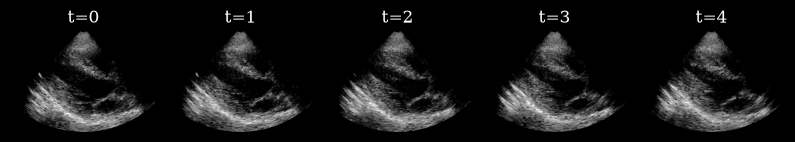

In [10]:
# Scan conversion turns the polar images into a fan, using the angles of the recording.
scan_convert = Pipeline([ScanConvert(order=2, jit_compile=False)])
parameters_sc = scan_convert.prepare_parameters(
    theta_range=(parameters.polar_angles.min(), parameters.polar_angles.max()),
    rho_range=config.parameters.zlims,
)

# Convert the polar data into a fan-shape
target_sequence_sc = scan_convert(data=target_sequence, **parameters_sc)["data"]

# We plot the first 5 frames
n_frames_to_plot = min(5, n_frames)
fig, _ = plot_image_grid(
    target_sequence_sc[:n_frames_to_plot],
    titles=[f"t={t}" for t in range(n_frames_to_plot)],
    ncols=n_frames_to_plot,
    remove_axis=True,
    vmin=vmin,
    vmax=vmax,
)

## 3. Reconstruct with a subset of transmits

Every scan line costs one focused transmit, and every transmit costs time. Firing only a subset of the
lines makes a frame faster to acquire, which can be spent on a higher frame rate, or on other
measurements such as Doppler. With 7 of the 56 lines, a frame takes an eighth of the time. However, now not the entire field of view is observed uniformly. The recovery of the missing data from the available measurements is an **inverse problem**. We solve it with a pretrained generative model that acts as a prior, and we use the variance in the reconstructions to choose which lines to acquire next.

`acquire` selects the requested transmits from the raw recording and beamforms those lines
using the shared brightness reference. It returns an image containing the measured lines
and a **mask**: ones at measured pixels and zeros elsewhere. The mask tells the model which
pixels contain observations.

The selector represents its choice as a vector with one entry per line: one means selected,
zero means unselected. This is called a *k-hot* vector when it contains k ones.

In [11]:
def acquire(raw_frame, selected_lines, mask):
    """Beamform the lines the agent selected, straight from the channel data.

    Args:
        raw_frame: `(n_transmits, n_samples, n_elements, 1)` channel data for one frame.
        selected_lines: `(1, n_lines)` k-hot action from the selection policy.
        mask: `(1, height, width)` the same action, at image size.

    Returns:
        The sparse measurement, `(1, height, width)`, and the mask it was taken with.
    """
    line_indices = np.flatnonzero(ops.convert_to_numpy(selected_lines)[0] > 0.5)
    lines_db, _ = reconstruct_data(
        raw_frame, line_indices=line_indices, maxval=reference_maxval
    )

    measurement = np.zeros((frame_height, n_lines), dtype="float32")
    measurement[:, line_indices] = ops.convert_to_numpy(to_model_range(lines_db))
    measurement = np.repeat(measurement, columns_per_line, axis=1)
    return ops.convert_to_tensor(measurement)[None] * mask, mask

For this first example, we choose `n_actions` lines at random.

In [12]:
n_actions = 7  # scan lines per frame, out of 56

random_line_selector = UniformRandomLines(
    n_actions=n_actions,
    n_possible_actions=n_lines,
    img_width=frame_width,
    img_height=frame_height,
)
selected_lines, measurement_mask = random_line_selector.sample(batch_size=1)
measurements, measurement_mask = acquire(
    raw_frames[0], selected_lines, measurement_mask
)

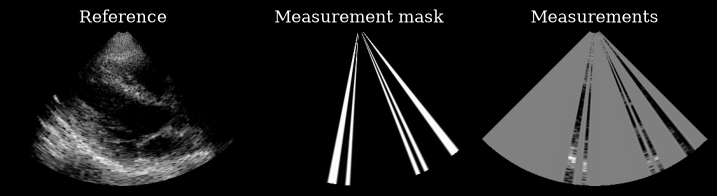

In [13]:
# @title Plot the reference, measurement mask and measurements
mask_sc = scan_convert(
    data=ops.cast(measurement_mask, "float32"), **(parameters_sc | {"fill_value": 0.0})
)["data"]
measurements_sc = scan_convert(data=measurements, **parameters_sc)["data"]
fig, _ = plot_image_grid(
    [
        target_sequence_sc[0],
        translate(mask_sc[0], (0, 1), (vmin, vmax)),
        measurements_sc[0],
    ],
    titles=["Reference", "Measurement mask", "Measurements"],
    ncols=3,
    figsize=(9, 4),
    vmin=vmin,
    vmax=vmax,
)

With only a few lines $a$ acquired, most field of view is missing from the reconstruction. Recovering the full frame from these
sparse measurements $y$ is an *inverse problem*: many reconstructed images $x$ agree with the lines $a$ we measured, so
the measurements alone cannot tell us which one is correct. To fill in the gaps, we need prior
knowledge of what cardiac ultrasound images look like.

Let $x$ be the full image, $y$ the measurements and $a$ the acquired lines (actions you toook). Acquiring a subset of lines keeps only
the pixels in the measurement mask $M$, so $y = M \odot x$. Bayes' rule combines what we measured with what we know beforehand:

$$
p(x \mid y, a) = \frac{p(y \mid x, a)\, p(x)}{p(y)} \propto p(y \mid x, a)\, p(x)
$$`

- $p(x)$ is the **prior**: which images are plausible hearts, before measuring anything.
- $p(y \mid x, a)$ is the **likelihood**: how well an image $x$ agrees with the measured lines $y$.
- $p(x \mid y, a)$ is the **posterior**: which images are plausible hearts *and* agree with the measurements.

## 4. A generative model as prior

That prior knowledge comes from a pretrained flow-matching model, trained on echocardiography
data. The model has learned the prior $p(x)$, and can draw new samples from it. It generates short clips of consecutive frames in the same $224 \times 112$ polar image
format we prepared above. We first look at what the model generates on its own, and then
condition it on our sparse measurements in section 5.

In [14]:
# The model channels represent consecutive frames, ordered oldest to newest.
model = FlowMatchingModel.from_preset("hf://zeahub/flowmatching-echonetlvh/3ch-224x112")
n_model_frames = model.input_shape[-1]

# The model works on the same image size and value range we prepared in section 2.
assert tuple(model.input_shape[:2]) == (frame_height, frame_width)
assert tuple(model.input_range) == (vmin, vmax)

First, let's generate clips from the model without using any measurements. 
These are samples $x \sim p(x)$ from the model's **prior**. 
We call a collection of possible reconstructions our *belief*; the policy
code calls its samples *particles*.

The last panel shows the variance across samples. Look for regions where the generated
images differ. Variance indicates disagreement between samples, rather than a measured
reconstruction error. For display, we clip the highest one percent of variance values and
scale the remaining values to the plot range; separately scaled plots are not directly
comparable in absolute variance.


In [15]:
n_prior_samples = 4  # number of samples we generate from the prior. This number determines variance spread.
n_unconditional_steps = (
    100  # number of diffusion/flow matching steps for generating prior clips.
)

prior_samples = model.sample(
    n_samples=n_prior_samples,
    n_steps=n_unconditional_steps,
    verbose=True,
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 89ms/step


Now we turn the pixel-wise variance of the prior samples into an image. Note that we only visualize the last frame of the clip that the model generates.

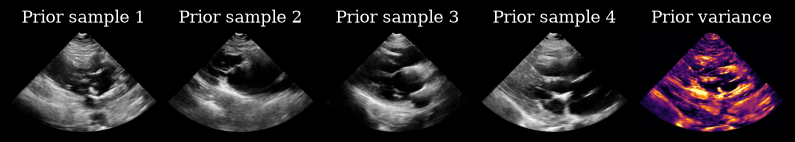

In [16]:
# @title Plot prior samples and their variance
def uncertainty_to_image(variance):
    """Map a variance map onto the image range so it can be plotted beside the images.

    Clip the top percentile so a few large values do not dominate the display.
    """
    upper = np.percentile(ops.convert_to_numpy(variance), 99)
    return translate(ops.clip(variance, 0.0, upper), (0.0, upper), (vmin, vmax))


prior_samples_sc = scan_convert(data=prior_samples[..., -1], **parameters_sc)["data"]
prior_variance_sc = scan_convert(
    data=ops.var(prior_samples, axis=0, keepdims=True)[..., -1],
    **(parameters_sc | {"fill_value": 0.0}),
)["data"]

panels = [*prior_samples_sc, uncertainty_to_image(prior_variance_sc[0])]
titles = [
    *[f"Prior sample {i + 1}" for i in range(n_prior_samples)],
    "Prior variance",
]
fig, _ = plot_image_grid(
    panels,
    titles=titles,
    ncols=len(panels),
    vmin=vmin,
    vmax=vmax,
    cmap=["gray"] * n_prior_samples + ["inferno"],
)

## 5. Use the model to complete subsampled data

In this section we condition the model on the sparse measurements from section 3, and show
how it can complete the missing data with **posterior sampling**: drawing samples
$x \sim p(x \mid y)$ instead of $x \sim p(x)$.


**Posterior samples** $x \sim p(x \mid y)$ are plausible
reconstructions conditioned on the randomly selected lines we measured.

The model expects `n_model_frames` consecutive frames, so we keep matching windows of
measurements and masks, ordered oldest to newest. Initially only the latest frame has
measurements. Earlier entries have zero masks and do not contribute measurement guidance.

The last frame in each prior clip will guide the first line selection in the sequence loop.
It does not initialize the first posterior update, which starts from noise.


The settings below control posterior sampling. `conditional_omega` sets the measurement
guidance strength, and `n_conditional_steps` sets the full flow schedule length. Start with
these defaults while exploring the line budget.


In [17]:
n_conditional_samples = 2
n_conditional_steps = 200
conditional_omega = 1.0

In [18]:
def fifo_shift(buffer, new_frame):
    """Append `new_frame` to `buffer` along the last (time) axis, dropping the oldest."""
    return ops.concatenate([buffer[..., 1:], new_frame], axis=-1)


# Drop the first measurement into the newest slot of an otherwise empty window.
empty_window = ops.zeros((1, frame_height, frame_width, n_model_frames))
measurement_buffer = fifo_shift(empty_window, measurements[..., None])
mask_buffer = fifo_shift(empty_window, measurement_mask[..., None])

In [19]:
# Now we use this mask and the measurements to generate posterior samples with the model.
posterior_samples = model.posterior_sample(
    measurements=measurement_buffer,
    mask=mask_buffer,
    n_samples=n_conditional_samples,
    n_steps=n_conditional_steps,
    omega=conditional_omega,
    initial_step=0,
)

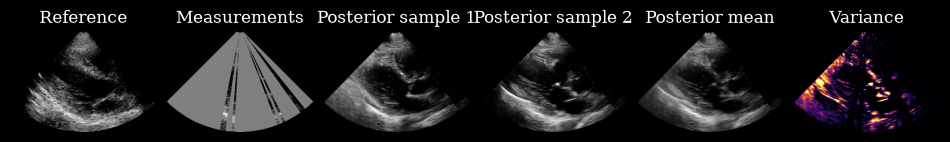

In [20]:
# @title Plot posterior samples, mean and variance
posterior_samples_sc = scan_convert(data=posterior_samples[..., -1], **parameters_sc)[
    "data"
]
measurements_sc = scan_convert(data=measurements, **parameters_sc)["data"]
variances_sc = scan_convert(
    data=ops.var(posterior_samples, axis=0, keepdims=True)[..., -1],
    **(parameters_sc | {"fill_value": 0.0}),
)["data"]
posterior_mean_sc = scan_convert(
    data=ops.mean(posterior_samples, axis=0, keepdims=True)[..., -1], **parameters_sc
)["data"]

panels = [
    target_sequence_sc[0],
    measurements_sc[0],
    *posterior_samples_sc,
    posterior_mean_sc[0],
    uncertainty_to_image(variances_sc[0]),
]
titles = [
    "Reference",
    "Measurements",
    *[f"Posterior sample {i + 1}" for i in range(n_conditional_samples)],
    "Posterior mean",
    "Variance",
]
fig, ims = plot_image_grid(
    panels,
    titles=titles,
    ncols=len(panels),
    vmin=vmin,
    vmax=vmax,
    cmap=["gray"] * (len(panels) - 1) + ["inferno"],
)

Compare these with the measurements alone and with the prior samples we generated earlier;

where do they agree closely, and where do they differ?

## 6. Adaptively selecting transmit lines

The policy we propose, `GreedyVariance`, uses disagreement between samples to decide where to measure:

1. Compute the variance at each pixel.
2. Sum it over depth and combine the two model columns belonging to each scan line.
3. Select the line with the highest score, reduce the scores of nearby lines, and repeat
   until the line budget is used.

Reducing nearby scores encourages the policy to spread its measurements across the image.
We inherit the line-mask and score-reweighting helpers from `GreedyEntropy`, but replace its
entropy score with variance as a simple initial policiy.

📝 Read the three steps in `sample` below. Which part would you change to try a different
uncertainty score?


In [21]:
class GreedyVariance(GreedyEntropy):
    """Greedily select the lines with maximum variance."""

    def sample(self, particles):
        """Sample the action using the greedy variance method.

        Args:
            particles (Tensor): Particles of shape (batch_size, n_particles, height, width)

        Returns:
            Tuple[Tensor, Tensor]:
                - Newly selected lines as k-hot vectors, shaped (batch_size, n_possible_actions)
                - Masks of shape (batch_size, img_height, img_width)
        """
        pixelwise_variance = ops.var(particles, axis=1)  # [batch_size, height, width]
        # Sum over depth to score each model column.
        columnwise_variance = ops.sum(pixelwise_variance, axis=1)  # [batch_size, width]
        # Combine the model columns belonging to each acquired line.
        linewise_variance = ops.sum(
            ops.reshape(
                columnwise_variance, (-1, self.n_possible_actions, self.stack_n_cols)
            ),
            axis=2,
        )  # [batch_size, n_possible_actions]

        # Greedily select best line, reweight variances, and repeat
        all_selected_lines = []
        for _ in range(self.n_actions):
            max_variance_line = ops.argmax(linewise_variance, axis=1)
            linewise_variance = self.reweight_entropies_around_line_vmap(
                linewise_variance, max_variance_line
            )
            all_selected_lines.append(max_variance_line)

        selected_lines_k_hot = masks.indices_to_k_hot(
            ops.stack(all_selected_lines, axis=1), self.n_possible_actions
        )
        return selected_lines_k_hot, self.lines_to_im_size(selected_lines_k_hot)

At each frame we acquire the chosen lines, update the posterior, and choose lines for the
next frame. The first update starts from noise. Later updates use [_SeqDiff_](https://ieeexplore.ieee.org/document/10889752), reusing the previous posterior
samples, starting at `n_initial_conditional_steps` within the full flow schedule. Only the
measurement and mask windows shift in time; the initial samples are reused as returned.

Since we generate multiple potential reconstructions (posterior samples) at each step, we don't by default have single 'solution' image to represent each frame. How we map from our posterior samples to a single reconstruction image is therefore a choice we need to make, considering various factors like reconstruction quality, perceptual quality, and interpretability.

📝 The current `get_reconstruction` function simply averages the posterior samples, returning the posterior mean as a reconstruction. Can you think of ways to improve this?

In [22]:
def get_reconstruction(
    samples, measurements=None, measurement_masks=None, hard_project=False
):
    """Average posterior samples, optionally restoring the measured pixels exactly."""
    reconstruction = ops.mean(samples, axis=1)
    if not hard_project:
        return reconstruction
    if measurements is None or measurement_masks is None:
        raise ValueError("Hard projection requires measurements and measurement masks")
    measured = measurements[:, 0, ..., None]
    measured_mask = ops.cast(measurement_masks[:, 0, ..., None], "bool")
    return ops.where(measured_mask, measured, reconstruction)

In [23]:
def run_perception_action_loop(raw_frames, action_selector):
    # Greedy variance acts on the prior belief at t=0. The baseline selectors accept
    # the same argument but deliberately ignore it.
    selected_lines, measurement_mask = action_selector.sample(
        prior_samples[None, ..., -1]
    )

    previous_samples = None
    # The last `n_model_frames` measurements and masks, oldest first.
    measurement_buffer = ops.zeros((1, frame_height, frame_width, n_model_frames))
    mask_buffer = ops.zeros_like(measurement_buffer)

    belief_distributions = []
    measurements = []
    measurement_masks = []
    for raw_frame in tqdm(raw_frames):
        measurements_t, measurement_mask_t = acquire(
            raw_frame, selected_lines, measurement_mask
        )
        measurement_buffer = fifo_shift(measurement_buffer, measurements_t[..., None])
        mask_buffer = fifo_shift(mask_buffer, measurement_mask_t[..., None])

        # Run the first frame from noise, then warm-start from each previous posterior.
        initial_step = 0 if previous_samples is None else n_initial_conditional_steps
        posterior_samples = model.posterior_sample(
            measurements=measurement_buffer,
            mask=mask_buffer,
            initial_samples=previous_samples,
            n_samples=n_conditional_samples,
            n_steps=n_conditional_steps,
            omega=conditional_omega,
            initial_step=initial_step,
            disable_jit=True,
        )
        # Keep the latest frame from each generated clip.
        belief = posterior_samples[..., -1:]

        selected_lines, measurement_mask = action_selector.sample(belief[None, ..., 0])

        # Keeping track of the belief distributions, measurements, and masks.
        belief_distributions.append(belief)
        measurements.append(measurements_t)
        measurement_masks.append(measurement_mask_t)
        previous_samples = posterior_samples

    return (
        ops.convert_to_tensor(belief_distributions),
        ops.convert_to_tensor(measurements),
        ops.convert_to_tensor(measurement_masks),
    )

In [24]:
# Starting step for updates that reuse previous samples.
n_initial_conditional_steps = 120

# Initialize the action selector and run the perception-action loop.
greedy_variance_action_selector = GreedyVariance(
    n_actions=n_actions,
    n_possible_actions=n_lines,
    img_width=frame_width,
    img_height=frame_height,
)
belief_distributions, measurements, measurement_masks = run_perception_action_loop(
    raw_frames, greedy_variance_action_selector
)

100%|██████████| 32/32 [00:09<00:00,  3.40it/s]


In [25]:
# Rerun this cell after changing get_reconstruction or hard_project.
hard_project = False  # replace reconstructed pixels with measurements where available

reconstructions = get_reconstruction(
    belief_distributions,
    measurements,
    measurement_masks,
    hard_project=hard_project,
)
reconstructions_sc = scan_convert(data=reconstructions[..., 0], **parameters_sc)["data"]
measurements_sc = scan_convert(data=measurements[:, 0, ...], **parameters_sc)["data"]
variances_sc = scan_convert(
    data=ops.var(belief_distributions, axis=1)[..., 0],
    **(parameters_sc | {"fill_value": 0.0}),
)["data"]
variances_sc = uncertainty_to_image(variances_sc)

### Watch the sequence

Compare the reconstruction with the reference as the sequence plays. Where do the samples
disagree? Do those regions correspond to visible reconstruction errors? Watch how the
selected lines change in the following frame.

Low variance means the samples agree; it does not by itself establish that the reconstruction
is accurate. Here variance is estimated from only `n_conditional_samples` samples.


In [26]:
# @title Animate reference, measurements, reconstruction and variance
fig, ims = plot_image_grid(
    [target_sequence_sc[0], measurements_sc[0], reconstructions_sc[0], variances_sc[0]],
    titles=["Reference", "Measurements", "Reconstruction", "Variance"],
    ncols=4,
    vmin=vmin,
    vmax=vmax,
    cmap=["gray"] * 3 + ["inferno"],
    figsize=(11, 4),
)


def update(frame):
    ims[0].set_array(target_sequence_sc[frame])
    ims[1].set_array(measurements_sc[frame])
    ims[2].set_array(reconstructions_sc[frame])
    ims[3].set_array(variances_sc[frame])

    return ims


ani = animation.FuncAnimation(
    fig, update, frames=len(target_sequence_sc), blit=True, interval=100
)
plt.close(fig)
HTML(ani.to_jshtml())

## 7. Compare selection policies

Does choosing lines from the current belief improve reconstruction on this recording?



Compare three policies with the same budget of `n_actions` lines per frame and the same
posterior sampling settings.

| Policy | Line selection |
| --- | --- |
| Equispaced sweep | Evenly spaced lines, shifted one line per frame |
| Uniform random | A new random subset each frame |
| Greedy variance | Lines with high sample variance, with nearby scores reduced |

We evaluate the posterior mean in the polar grid using PSNR (higher is better) and
[LPIPS](https://zea.readthedocs.io/en/latest/_autosummary/zea.models.lpips.html)
(lower is better). These compare reconstructions with the fully sampled reference.

The two baseline wrappers accept the same `sample(particles)` call as the adaptive policy,
but choose lines without using the samples. Running the next cells performs two additional
passes through the sequence.

In [27]:
class RandomLines(UniformRandomLines):
    """Belief-agnostic baseline: a fresh random subset of lines every frame."""

    def sample(self, particles):
        del particles  # a random policy has no use for the belief
        return super().sample(batch_size=1)


class SweepingLines(EquispacedLines):
    """Belief-agnostic baseline: an equispaced grid, swept one line further each frame."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.current_lines = None

    def sample(self, particles):
        del particles  # the sweep is scripted in advance
        self.current_lines, mask = super().sample(self.current_lines)
        return self.current_lines, mask

In [28]:
# We load in the LPIPS model for evaluation of perceptual similarity
lpips_model = LPIPS.from_preset("lpips")

In [29]:
# @title Evaluation helpers (PSNR and LPIPS)
def to_lpips(sequence):
    """Grayscale in the model's range -> rgb in [-1, 1], which is what lpips expects."""
    return ops.repeat(translate(sequence, (vmin, vmax), (-1, 1))[..., None], 3, axis=-1)


def evaluate(reconstruction, target):
    """Score a reconstructed sequence against its target, in the polar domain."""
    reconstruction = ops.clip(reconstruction, vmin, vmax)
    psnr = metrics.psnr(target, reconstruction, max_val=vmax - vmin)
    lpips = ops.mean(lpips_model((to_lpips(reconstruction), to_lpips(target))))
    return float(psnr), float(lpips)

In [30]:
selector_kwargs = {
    "n_actions": n_actions,
    "n_possible_actions": n_lines,
    "img_width": frame_width,
    "img_height": frame_height,
}
baselines = {
    "Equispaced sweep": SweepingLines(**selector_kwargs, assert_equal_spacing=False),
    "Uniform random": RandomLines(**selector_kwargs),
}

# Save samples and measurements so reconstruction choices can be compared cheaply.
policy_samples = {
    "Greedy variance": (belief_distributions, measurements, measurement_masks)
}
for name, action_selector in baselines.items():
    print(name)
    policy_samples[name] = run_perception_action_loop(raw_frames, action_selector)

Equispaced sweep


100%|██████████| 32/32 [00:06<00:00,  4.79it/s]


Uniform random


100%|██████████| 32/32 [00:06<00:00,  4.77it/s]


### Recompute reconstructions and scores

This cell uses the saved samples from all three policies.


In [31]:
# Rerun this cell after changing get_reconstruction or hard_project.
runs = {}
table = [["Policy", "PSNR (↑)", "LPIPS (↓)"]]
for name, (samples, observed, observed_mask) in policy_samples.items():
    reconstruction = get_reconstruction(
        samples, observed, observed_mask, hard_project=hard_project
    )[..., 0]
    runs[name] = reconstruction
    psnr, lpips = evaluate(reconstruction, target_sequence)
    table.append([name, f"{psnr:.2f}", f"{lpips:.3f}"])

print(tabulate(table, headers="firstrow", tablefmt="simple"))

Policy              PSNR (↑)    LPIPS (↓)
----------------  ----------  -----------
Greedy variance        19.67        0.445
Equispaced sweep       19.1         0.452
Uniform random         19.17        0.449


Compare the scores above, then inspect the middle frame below. Does the policy with the
best score also preserve the structures you are looking at?

Posterior sampling and random line selection can change the results between runs. A single
run on one recording is an example, rather than evidence that one policy is always better.


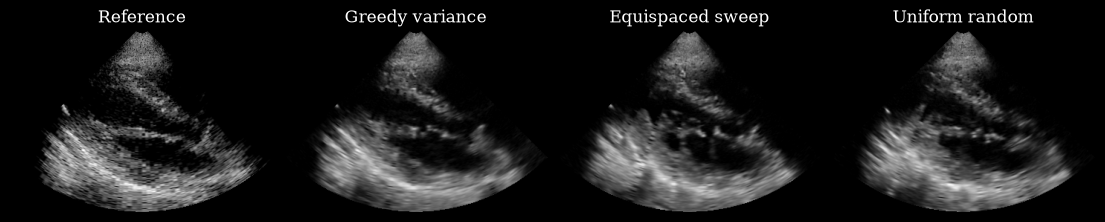

In [32]:
# @title Plot the middle frame for each policy
frame = len(target_sequence) // 2
panels = [target_sequence_sc[frame]]
titles = ["Reference"]
for name, reconstruction in runs.items():
    panels.append(
        scan_convert(data=reconstruction[frame][None], **parameters_sc)["data"][0]
    )
    titles.append(name)

fig, _ = plot_image_grid(
    panels,
    titles=titles,
    ncols=len(panels),
    vmin=vmin,
    vmax=vmax,
    figsize=(14, 4),
)

## 8. Experiment for yourself!

Change one thing at a time, and record the scores before and after.

---

### 1. Increase the line budget

- **Change:** set `n_actions` in section 3 from `7` to `4`, or `14`.
- **Rerun:** from that cell onward.
- 📝 Compare all three policies. Does their relative performance change?

### 2. Compare the mean with one sample

- **Change:** in `get_reconstruction`, replace `ops.mean(samples, axis=1)` with `samples[:, 0, ...]`.
- **Rerun:** the function cell, then the reconstruction, animation and scoring cells.
  The saved `policy_samples` dictionary lets you recompute all scores without resampling.
- 📝 Which structures and metrics change?

### 3. Restore measured pixels

- **Change:** set `hard_project = True` in the reconstruction cell.
- **Rerun:** that cell, the animation, and the scoring and comparison plot cells.
  No posterior sampling rerun is needed.
- 📝 Which metric changes more?

### Optional: how the measurements are formed

The recording stores channel data with axes:

```text
(frames, transmits, time samples, receive elements, channels)
```

There are 56 focused transmits across a ±45° sector. The config in `pipeline/pipeline.yaml`
defines this pipeline:

```text
select_scanlines → cast → band_pass_filter → apply_window → demodulate
    → map_scanlines[
          tof_correction → delay_and_sum → reshape_grid → envelope_detect
      ]
    → stack_scanlines → normalize → log_compress
```

The three custom operations in `pipeline/ops.py`:

| Operation | What it does |
| --- | --- |
| `select_scanlines` | selects the requested transmits |
| `map_scanlines` | beamforms each line from its own transmit |
| `stack_scanlines` | stacks the resulting columns into an image |

With the shared normalization reference, a selected line has the same brightness scale in
a sparse query and in the fully sampled reference. Each of the 56 lines is repeated into
two adjacent columns to match the model's 112-column input.

📝 Explore how pipeline parameters such as normalization and dynamic range affect the reconstructions. Can you find a way to improve the pipeline and boost reconstruction performance?

---

See you at IUS 2026! 🎉